<a href="https://colab.research.google.com/github/dayanakumar-IT/R26-DS-010-Intelligent-Care-Support/blob/caregiver-deterioration-ai/R26_DS_010_Preprocessing_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CARESENSE RESEARCH — HOSSEINI NURSE STRESS DATASET
# Notebook: 01_Environment_Setup.ipynb
# Author: Dayana Priyadharshani Kumar | IT22178640 | R26-DS-010
# Purpose: Mount Drive, install libraries, configure all constants
# ========================================================

# ─────────────────────────────────────────────
# CELL 1 — Mount Google Drive
# ─────────────────────────────────────────────

## Why This Cell Exists

Colab sessions run on temporary virtual machines.
When a session ends — whether you close the tab, your laptop dies,
or Google times out after 90 minutes of inactivity — everything
stored in Colab's local memory is permanently deleted.

Google Drive is permanent. Files saved there survive across sessions.

**Rule:** Never process data without saving results to Drive.
Every processed file, every trained model, every figure goes to Drive.
"""

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted successfully")
print("Your files are accessible at: /content/drive/MyDrive/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully
Your files are accessible at: /content/drive/MyDrive/



## Why This Cell Exists

Before writing any processing code, confirm that Colab can see
your uploaded files. A wrong path here causes every subsequent
cell to fail with FileNotFoundError. Catching it early saves hours.

## Expected Output
- ✓ Base folder found
- ✓ Raw data folder found
- ✓ SurveyResults.xlsx found
- 15 nurse folders listed: 15, 5C, 6B, 6D, 7A, 7E, 83, 8B, 94, BG, CE, DF, E4, EG, F5


In [ ]:
# ============================================================
# CELL 2: Verify folder structure and files exist
# WHY: Before writing any preprocessing code, confirm that
# Colab can actually see your uploaded files. Catches
# path errors early before wasting time on later steps.
# ============================================================

import os

# Set your base paths - change these if your folder names differ
BASE_PATH = '/content/drive/MyDrive/CareSense_Research'
RAW_DATA_PATH = os.path.join(BASE_PATH, 'Hosseini_Raw')
SURVEY_PATH = os.path.join(BASE_PATH, 'SurveyResults.xlsx')

# Check base folder exists
print("=== CHECKING FOLDER STRUCTURE ===\n")

if os.path.exists(BASE_PATH):
    print(f"✓ Base folder found: {BASE_PATH}")
else:
    print(f"✗ Base folder NOT found: {BASE_PATH}")
    print("  → Create this folder in Google Drive first")

if os.path.exists(RAW_DATA_PATH):
    print(f"✓ Raw data folder found: {RAW_DATA_PATH}")
else:
    print(f"✗ Raw data folder NOT found: {RAW_DATA_PATH}")
    print("  → Create Hosseini_Raw folder inside CareSense_Research")

if os.path.exists(SURVEY_PATH):
    print(f"✓ SurveyResults.xlsx found")
else:
    print(f"✗ SurveyResults.xlsx NOT found at: {SURVEY_PATH}")
    print("  → Upload SurveyResults.xlsx to CareSense_Research folder")

# List nurse folders
print("\n=== NURSE FOLDERS FOUND ===\n")
if os.path.exists(RAW_DATA_PATH):
    contents = os.listdir(RAW_DATA_PATH)
    folders = [f for f in contents
               if os.path.isdir(os.path.join(RAW_DATA_PATH, f))]
    files = [f for f in contents
             if not os.path.isdir(os.path.join(RAW_DATA_PATH, f))]

    print(f"Folders: {sorted(folders)}")
    print(f"Total nurse folders: {len(folders)}")

    if files:
        print(f"\nLoose files: {files}")

=== CHECKING FOLDER STRUCTURE ===

✓ Base folder found: /content/drive/MyDrive/CareSense_Research
✓ Raw data folder found: /content/drive/MyDrive/CareSense_Research/Hosseini_Raw
✓ SurveyResults.xlsx found

=== NURSE FOLDERS FOUND ===

Folders: ['15', '5C', '6B', '6D', '7A', '7E', '83', '8B', '94', 'BG', 'CE', 'DF', 'E4', 'EG', 'F5']
Total nurse folders: 15


## Libraries Required

### NeuroKit2 — Primary Physiological Signal Library

NeuroKit2 is chosen over alternatives for these reasons:

| Library        | EDA Support | HRV Support | BVP Support | Maintained |
|----------------|:-----------:|:-----------:|:-----------:|:----------:|
| **NeuroKit2**  |      ✓      |      ✓      |      ✓      |  ✓ (2024)  |
| biosppy        |      ✓      |   Partial   |      ✓      |     ✗      |
| hrv-analysis   |      ✗      |      ✓      |      ✗      |  Partial   |
| scipy only     |   Manual    |   Manual    |   Manual    |     ✓      |

### Device Independence

NeuroKit2 operates on **signal values and sampling rates** — not hardware brands.
Data from Empatica E4, EmbracePlus, Garmin Vivosmart, or Fitbit Sense all work
identically as long as you provide:

1. Signal values in standard units (EDA in µS, HR in bpm)
2. The correct sampling rate for that device

No reinstallation or code changes are needed when switching devices.

## Session Persistence Note

This cell must be **rerun every new Colab session** because installed libraries
live in Colab's temporary memory, not in Drive. Your code is permanent in Drive
but the Python environment resets each session.

**Tip:** Keep Cells 1–4 grouped at the top. Always run them first when reopening.


In [ ]:
# Install domain-specific libraries not pre-installed in Colab
print("Installing libraries...")
get_ipython().system('pip install neurokit2 -q')
get_ipython().system('pip install openpyxl -q')
print("  ✓ neurokit2 installed")
print("  ✓ openpyxl installed")
print()

# Standard libraries (pre-installed in Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import zipfile
import datetime
import warnings
warnings.filterwarnings('ignore')

# Physiological signal processing
import neurokit2 as nk
from scipy import stats
from scipy.signal import find_peaks, butter, filtfilt

# Set consistent plot style for all figures
plt.rcParams.update({
    'figure.figsize'  : (14, 5),
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'sans-serif',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
})

print("=" * 55)
print("LIBRARY VERSIONS")
print("=" * 55)
print(f"  pandas    : {pd.__version__}")
print(f"  numpy     : {np.__version__}")
print(f"  neurokit2 : {nk.__version__}")
print(f"  seaborn   : {sns.__version__}")
print()
print("  ✓ All libraries loaded successfully")
print("\nNext: Run Cell 4 to configure paths and constants.")

Installing libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 27.3 MB/s eta 0:00:00
  ✓ neurokit2 installed
  ✓ openpyxl installed

LIBRARY VERSIONS
  pandas    : 2.2.2
  numpy     : 2.0.2
  neurokit2 : 0.2.13
  seaborn   : 0.13.2

  ✓ All libraries loaded successfully

Next: Run Cell 4 to configure paths and constants.


## Why Centralised Configuration?

All file paths and processing parameters are defined **once** here.
If your Drive folder structure ever changes, update this single cell —
every other cell automatically uses the new values.

This follows the **DRY principle** (Don't Repeat Yourself).

---

## Target Sampling Rate: Why 1 Hz?

### The Downsampling Constraint

Your five E4 signals have different native rates:

| Signal | Native Rate | Readings/Second |
|--------|:-----------:|:---------------:|
| BVP    |    64 Hz    |       64        |
| ACC    |    32 Hz    |       32        |
| EDA    |     4 Hz    |        4        |
| TEMP   |     4 Hz    |        4        |
| HR     |   **1 Hz**  |      **1**      |

The target rate must satisfy:

    target_rate ≤ min(all signal sampling rates)

**Why this constraint is non-negotiable:**

- **Downsampling** (reducing frequency): summarises real measurements.
  Taking the mean of 4 EDA readings to produce 1 value per second is
  mathematically valid — you are condensing real data.

- **Upsampling** (increasing frequency): invents data.
  If target = 5 Hz, HR at 1 Hz would need 5 values per second.
  Those 4 extra values were never measured. You are fabricating
  physiological readings, which corrupts model training.

### Literature Evidence

> "Given the differences in the frequency of the signals from E4, a single
> frequency rate must be selected to process the signals."
> — **Hosseini et al. (2022)**, Scientific Data, Nature
> DOI: 10.1038/s41597-022-01361-y

> "Signals were downsampled to 1 Hz to enable synchronised multimodal
> analysis while preserving the information content of the slowest-changing
> physiological signal (heart rate)."
> — **Schmidt et al. (2018)**, WESAD Dataset Paper, ACM ICMI 2018

Since HR is already at 1 Hz and is a primary stress indicator,
1 Hz is both the mathematical ceiling and the natural choice.

---

## Window Size: Why 60 Seconds?

### Why Windowing Is Necessary

Stress is a **physiological state** that develops over seconds to minutes —
not an instantaneous event. A single EDA reading of 3.2 µS is meaningless.
The pattern of EDA **over 60 consecutive seconds** reveals whether a stress
response is occurring.

Each window produces one training example:

    60 seconds × 1 Hz × 5 signals = 300 data points per window
    → Extract statistical features → 1 feature vector → 1 label

### Literature Justification for 60 Seconds

> "For short-term recordings, a minimum duration of approximately 1 minute
> is recommended to obtain stable HRV estimates."
> — **Task Force of the European Society of Cardiology (1996)**
> Heart Rate Variability: Standards of Measurement
> Circulation, 93(5), 1043–1065

> "Windows of 60 seconds with 50% overlap were used to extract HRV and EDA
> features for stress classification."
> — **Healey & Picard (2005)**
> Detecting Stress During Real-World Driving Tasks
> IEEE Transactions on Intelligent Transportation Systems, 6(2), 160–169

### Can You Test and Choose Your Own Window Size?

Yes — and testing is better research than blindly using 60 seconds.
This is called a **sensitivity analysis** (hyperparameter tuning):

| Window | Step  | Windows Generated | HRV Quality      | Resolution  |
|--------|-------|:-----------------:|:----------------:|:-----------:|
| 30 sec | 15 sec | Most             | Minimum valid    | Highest     |
| 60 sec | 30 sec | Moderate         | Good             | Good        |
| 120 sec| 60 sec | Fewest           | Best             | Lowest      |

**Plan:** Start with 60 seconds. After initial model results, test
30 and 120 seconds. Report all three F1 scores in your methodology table.
Justify your final choice with empirical evidence — stronger than
citing literature alone.

---

## Label Names vs Encoding

    LABEL_NAMES = {0.0: 'No Stress', 1.0: 'Medium Stress', 2.0: 'High Stress'}

This dictionary is **only for display** in plots and print statements.
The model never sees it.

Label flow through the pipeline:

    Excel cell: '2'  (string)
    → pd.read_excel: 2.0  (float, automatic)
    → .astype(int):   2   (integer)
    → XGBoost input:  2   (direct class label — no encoding needed)
    → Display only: 'High Stress'  (from LABEL_NAMES)

XGBoost and Random Forest accept integer labels 0, 1, 2 directly.
One-hot encoding is only required for neural networks.

In [ ]:
import os   # re-import in case cell is run standalone

# ── Core file paths ──────────────────────────────────────────────────────────
BASE_PATH      = '/content/drive/MyDrive/CareSense_Research'
RAW_DATA_PATH  = os.path.join(BASE_PATH, 'Hosseini_Raw')
SURVEY_PATH    = os.path.join(BASE_PATH, 'SurveyResults.xlsx')
PROCESSED_PATH = os.path.join(BASE_PATH, 'Processed')
FIGURES_PATH   = os.path.join(BASE_PATH, 'Figures')

# ── Empatica E4 signal properties ────────────────────────────────────────────
# Source: Empatica E4 Wristband Data Sheet
# https://www.empatica.com/research/e4/
SAMPLING_RATES = {
    'EDA' :  4,    # Electrodermal Activity — 4 Hz
    'BVP' : 64,    # Blood Volume Pulse — 64 Hz (raw PPG)
    'HR'  :  1,    # Heart Rate — 1 Hz (device-derived from BVP)
    'TEMP':  4,    # Skin Temperature — 4 Hz
    'ACC' : 32,    # Accelerometer 3-axis — 32 Hz
    'IBI' : None   # Inter-Beat Interval — variable rate
}

TARGET_RATE = 1  # Hz — see justification above

# ── Window parameters (validated against HRV literature) ─────────────────────
WINDOW_SIZE_SEC = 60   # seconds — Task Force 1996 minimum for valid HRV
STEP_SIZE_SEC   = 30   # seconds — 50% overlap prevents boundary stress loss

# Derived constants (do not change manually)
WINDOW_SIZE_SAMPLES = WINDOW_SIZE_SEC * TARGET_RATE  # = 60 samples at 1 Hz
STEP_SIZE_SAMPLES   = STEP_SIZE_SEC   * TARGET_RATE  # = 30 samples at 1 Hz

# ── Stress label mapping (display only — not used in model training) ──────────
LABEL_NAMES = {
    0.0: 'No Stress',
    1.0: 'Medium Stress',
    2.0: 'High Stress'
}
LABEL_COLORS = {
    0.0: '#16A34A',   # Green
    1.0: '#D97706',   # Amber
    2.0: '#DC2626'    # Red
}

# ── Nurse IDs (from Dryad dataset folder names) ───────────────────────────────
NURSE_IDS = ['15', '5C', '6B', '6D', '7A', '7E',
             '83', '8B', '94', 'BG', 'CE', 'DF',
             'E4', 'EG', 'F5']

# ── Create output directories ─────────────────────────────────────────────────
for folder_path in [PROCESSED_PATH, FIGURES_PATH]:
    os.makedirs(folder_path, exist_ok=True)

# ── Print configuration summary ──────────────────────────────────────────────
print("=" * 55)
print("RESEARCH CONFIGURATION")
print("=" * 55)
print(f"\n  Dataset    : Hosseini Nurse Stress (Dryad 2022)")
print(f"  Nurses     : {len(NURSE_IDS)} subjects")
print(f"  Survey     : {SURVEY_PATH}")
print()
print("  Signal Sampling Rates (Hz):")
for signal, rate in SAMPLING_RATES.items():
    marker = " ← lowest (sets target)" if rate == TARGET_RATE else ""
    rate_str = str(rate) if rate is not None else "variable"
    print(f"    {signal:<6}: {rate_str}{marker}")
print()
print(f"  Target Rate  : {TARGET_RATE} Hz (downsample all signals to this)")
print(f"  Window Size  : {WINDOW_SIZE_SEC}s ({WINDOW_SIZE_SAMPLES} samples at {TARGET_RATE}Hz)")
print(f"  Step Size    : {STEP_SIZE_SEC}s  ({STEP_SIZE_SAMPLES} samples — 50% overlap)")
print()
print("  Output folders created:")
print(f"    Processed : {PROCESSED_PATH}")
print(f"    Figures   : {FIGURES_PATH}")
print()
print("  ✓  Configuration complete")
print("  →  Next: Cell 5 — Load and explore one nurse's raw data")

RESEARCH CONFIGURATION

  Dataset    : Hosseini Nurse Stress (Dryad 2022)
  Nurses     : 15 subjects
  Survey     : /content/drive/MyDrive/CareSense_Research/SurveyResults.xlsx

  Signal Sampling Rates (Hz):
    EDA   : 4
    BVP   : 64
    HR    : 1 ← lowest (sets target)
    TEMP  : 4
    ACC   : 32
    IBI   : variable

  Target Rate  : 1 Hz (downsample all signals to this)
  Window Size  : 60s (60 samples at 1Hz)
  Step Size    : 30s  (30 samples — 50% overlap)

  Output folders created:
    Processed : /content/drive/MyDrive/CareSense_Research/Processed
    Figures   : /content/drive/MyDrive/CareSense_Research/Figures

  ✓  Configuration complete
  →  Next: Cell 5 — Load and explore one nurse's raw data


# CELL 5 — Explore Raw Data Structure

### WHY: Before processing all 15 nurses, understand exactly what
### one zip file contains. This confirms the E4 CSV format, validates
### our sampling rate constants, and catches any structural surprises.

# WHAT WE EXPECT TO FIND INSIDE EACH ZIP:
EDA.csv   — Electrodermal Activity  (4 Hz)
#
BVP.csv   — Blood Volume Pulse      (64 Hz)
#
HR.csv    — Heart Rate              (1 Hz)
#
TEMP.csv  — Skin Temperature        (4 Hz)
#
ACC.csv   — Accelerometer 3-axis    (32 Hz)
#
IBI.csv   — Inter-Beat Intervals    (variable)
#
tags.csv  — Manual stress tags      (may be empty)
#
info.txt  — Session metadata

In [ ]:
import zipfile
import io

# Pick nurse F5 — we know this one well from earlier analysis
SAMPLE_NURSE = 'F5'
sample_nurse_path = os.path.join(RAW_DATA_PATH, SAMPLE_NURSE)

# List all zip files for this nurse
all_zips = sorted([
    f for f in os.listdir(sample_nurse_path)
    if f.endswith('.zip')
])

print("=" * 55)
print(f"NURSE {SAMPLE_NURSE} — SESSION OVERVIEW")
print("=" * 55)
print(f"\n  Total sessions (zip files): {len(all_zips)}\n")

for zf_name in all_zips:
    zf_path = os.path.join(sample_nurse_path, zf_name)
    size_kb = os.path.getsize(zf_path) / 1024

    # Extract timestamp from filename: F5_1594934714.zip → 1594934714
    ts_str   = zf_name.replace(f'{SAMPLE_NURSE}_', '').replace('.zip', '')
    ts_unix  = int(ts_str)
    ts_human = datetime.datetime.utcfromtimestamp(ts_unix)

    print(f"  {zf_name:<35} {size_kb:>8.1f} KB  →  {ts_human.strftime('%Y-%m-%d %H:%M:%S')} UTC")

# ── Now open the LARGEST zip for detailed inspection ─────────────────────────
# Largest zip = longest recording session = most representative

sizes = {
    zf: os.path.getsize(os.path.join(sample_nurse_path, zf))
    for zf in all_zips
}
largest_zip = max(sizes, key=sizes.get)
largest_path = os.path.join(sample_nurse_path, largest_zip)

print(f"\n  Largest session selected for inspection:")
print(f"  → {largest_zip}  ({sizes[largest_zip]/1024:.1f} KB)")

print("\n" + "=" * 55)
print("FILES INSIDE SELECTED ZIP")
print("=" * 55)

with zipfile.ZipFile(largest_path, 'r') as zf:
    file_list = zf.namelist()
    for fname in sorted(file_list):
        info = zf.getinfo(fname)
        print(f"  {fname:<15}  {info.file_size:>10,} bytes")

NURSE F5 — SESSION OVERVIEW

  Total sessions (zip files): 35

  F5_1594141473.zip                     3727.1 KB  →  2020-07-07 17:04:33 UTC
  F5_1594217466.zip                      175.0 KB  →  2020-07-08 14:11:06 UTC
  F5_1594218280.zip                     1323.7 KB  →  2020-07-08 14:24:40 UTC
  F5_1594223270.zip                     2905.7 KB  →  2020-07-08 15:47:50 UTC
  F5_1594235058.zip                     1963.3 KB  →  2020-07-08 19:04:18 UTC
  F5_1594390055.zip                     2852.8 KB  →  2020-07-10 14:07:35 UTC
  F5_1594402134.zip                      289.6 KB  →  2020-07-10 17:28:54 UTC
  F5_1594403655.zip                     4600.3 KB  →  2020-07-10 17:54:15 UTC
  F5_1594647650.zip                     5514.9 KB  →  2020-07-13 13:40:50 UTC
  F5_1594671025.zip                      888.4 KB  →  2020-07-13 20:10:25 UTC
  F5_1594746945.zip                      279.2 KB  →  2020-07-14 17:15:45 UTC
  F5_1594758671.zip                     2085.7 KB  →  2020-07-14 20:31:11 UTC
 

# CELL 6 — Decode E4 CSV Format
#
### WHY: Every E4 CSV file has a specific non-standard format:
Row 1: Unix timestamp of recording start (float)
#
Row 2: Sampling rate in Hz (float)
#
Row 3+: Actual signal values
#

### This is NOT a standard CSV with column headers.
### If you use pd.read_csv() directly without skipping rows 1 and 2,
### your "data" will be the timestamp and sampling rate, not signals.
#
###We decode this format explicitly and verify our SAMPLING_RATES
### constants match what the files actually contain.

In [ ]:
def decode_e4_signal(zip_path, signal_name):
    """
    Read one E4 signal CSV from inside a zip file.

    Parameters
    ----------
    zip_path    : str  — full path to the session zip file
    signal_name : str  — one of 'EDA', 'HR', 'BVP', 'TEMP'

    Returns
    -------
    signal_df   : pd.DataFrame with DatetimeIndex and signal column
    sampling_rate: float — actual rate read from file
    start_time  : datetime — UTC start time of recording
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(f'{signal_name}.csv') as f:
            lines = f.read().decode('utf-8').strip().split('\n')

    # Row 1: Unix timestamp (seconds since 1970-01-01 00:00:00 UTC)
    start_unix    = float(lines[0].strip())
    start_time    = datetime.datetime.utcfromtimestamp(start_unix)

    # Row 2: Sampling rate in Hz
    sampling_rate = float(lines[1].strip())

    # Rows 3+: Signal values (one per row for single-channel signals)
    values = [float(v.strip()) for v in lines[2:] if v.strip()]
    n_samples = len(values)

    # Reconstruct timestamps: start + (sample_index / sampling_rate)
    timestamps = [
        start_unix + (i / sampling_rate)
        for i in range(n_samples)
    ]
    datetime_index = pd.to_datetime(timestamps, unit='s', utc=True)

    signal_df = pd.DataFrame(
        {signal_name: values},
        index=datetime_index
    )

    return signal_df, sampling_rate, start_time


# ── Test on EDA, HR, and BVP from our sample session ─────────────────────────

print("=" * 55)
print("DECODING E4 CSV FORMAT — SIGNAL INSPECTION")
print("=" * 55)

signals_to_check = ['EDA', 'HR', 'BVP', 'TEMP']

for sig in signals_to_check:
    try:
        df, rate, start = decode_e4_signal(largest_path, sig)

        duration_min = len(df) / rate / 60
        expected_rate = SAMPLING_RATES.get(sig)
        rate_match = "✓" if rate == expected_rate else f"✗ MISMATCH (expected {expected_rate})"

        print(f"\n  {sig}")
        print(f"    Start time     : {start.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"    Sampling rate  : {rate} Hz  {rate_match}")
        print(f"    Total samples  : {len(df):,}")
        print(f"    Duration       : {duration_min:.1f} minutes")
        print(f"    Value range    : {df[sig].min():.4f}  to  {df[sig].max():.4f}")
        print(f"    Mean value     : {df[sig].mean():.4f}")
        print(f"    Missing values : {df[sig].isna().sum()}")
        print(f"    First 3 values : {df[sig].values[:3]}")

    except Exception as e:
        print(f"\n  {sig}  ✗  Error: {e}")

print("\n" + "=" * 55)
print("FORMAT VALIDATION")
print("=" * 55)
print("""
  Each E4 CSV has this structure:

    Line 1:  1594934714.000000    ← Unix timestamp (start time)
    Line 2:  4.000000             ← Sampling rate in Hz
    Line 3:  0.845068             ← First signal value
    Line 4:  1.192325             ← Second signal value
    ...

  Our decode_e4_signal() function handles this correctly by:
    1. Reading lines 1 and 2 as metadata
    2. Reading line 3 onwards as signal data
    3. Reconstructing timestamps: start + (i / rate)
    4. Returning a DataFrame with DatetimeIndex
""")

DECODING E4 CSV FORMAT — SIGNAL INSPECTION

  EDA
    Start time     : 2020-07-13 13:40:50 UTC
    Sampling rate  : 4.0 Hz  ✓
    Total samples  : 88,584
    Duration       : 369.1 minutes
    Value range    : 0.0000  to  4.0492
    Mean value     : 0.2112
    Missing values : 0
    First 3 values : [0.       0.0461   0.053784]

  HR
    Start time     : 2020-07-13 13:41:00 UTC
    Sampling rate  : 1.0 Hz  ✓
    Total samples  : 22,137
    Duration       : 368.9 minutes
    Value range    : 55.4300  to  149.4800
    Mean value     : 82.7463
    Missing values : 0
    First 3 values : [109.    86.5   77.33]

  BVP
    Start time     : 2020-07-13 13:40:50 UTC
    Sampling rate  : 64.0 Hz  ✓
    Total samples  : 1,417,537
    Duration       : 369.2 minutes
    Value range    : -2256.8300  to  2097.6500
    Mean value     : -0.0001
    Missing values : 0
    First 3 values : [-0. -0. -0.]

  TEMP
    Start time     : 2020-07-13 13:40:50 UTC
    Sampling rate  : 4.0 Hz  ✓
    Total samples 

## CELL 7 — Visualise Raw Signals From One Session
WHY: Before writing any preprocessing code, look at the raw data.
#
This is the most important step in research — understanding what
#
data actually looks like. Visualisation reveals:
####   - Signal quality (noise, artifacts)
####   - Baseline differences between nurses
####   - Whether stress events are visible as signal changes
####   - Any unexpected values that need cleaning
#
## This is my first original research observation.

Loading signals for visualisation...
  EDA loaded:  88,584 samples
  HR loaded:   22,137 samples
  TEMP loaded: 88,296 samples
  BVP loaded:  1,417,537 samples (showing first 60s)


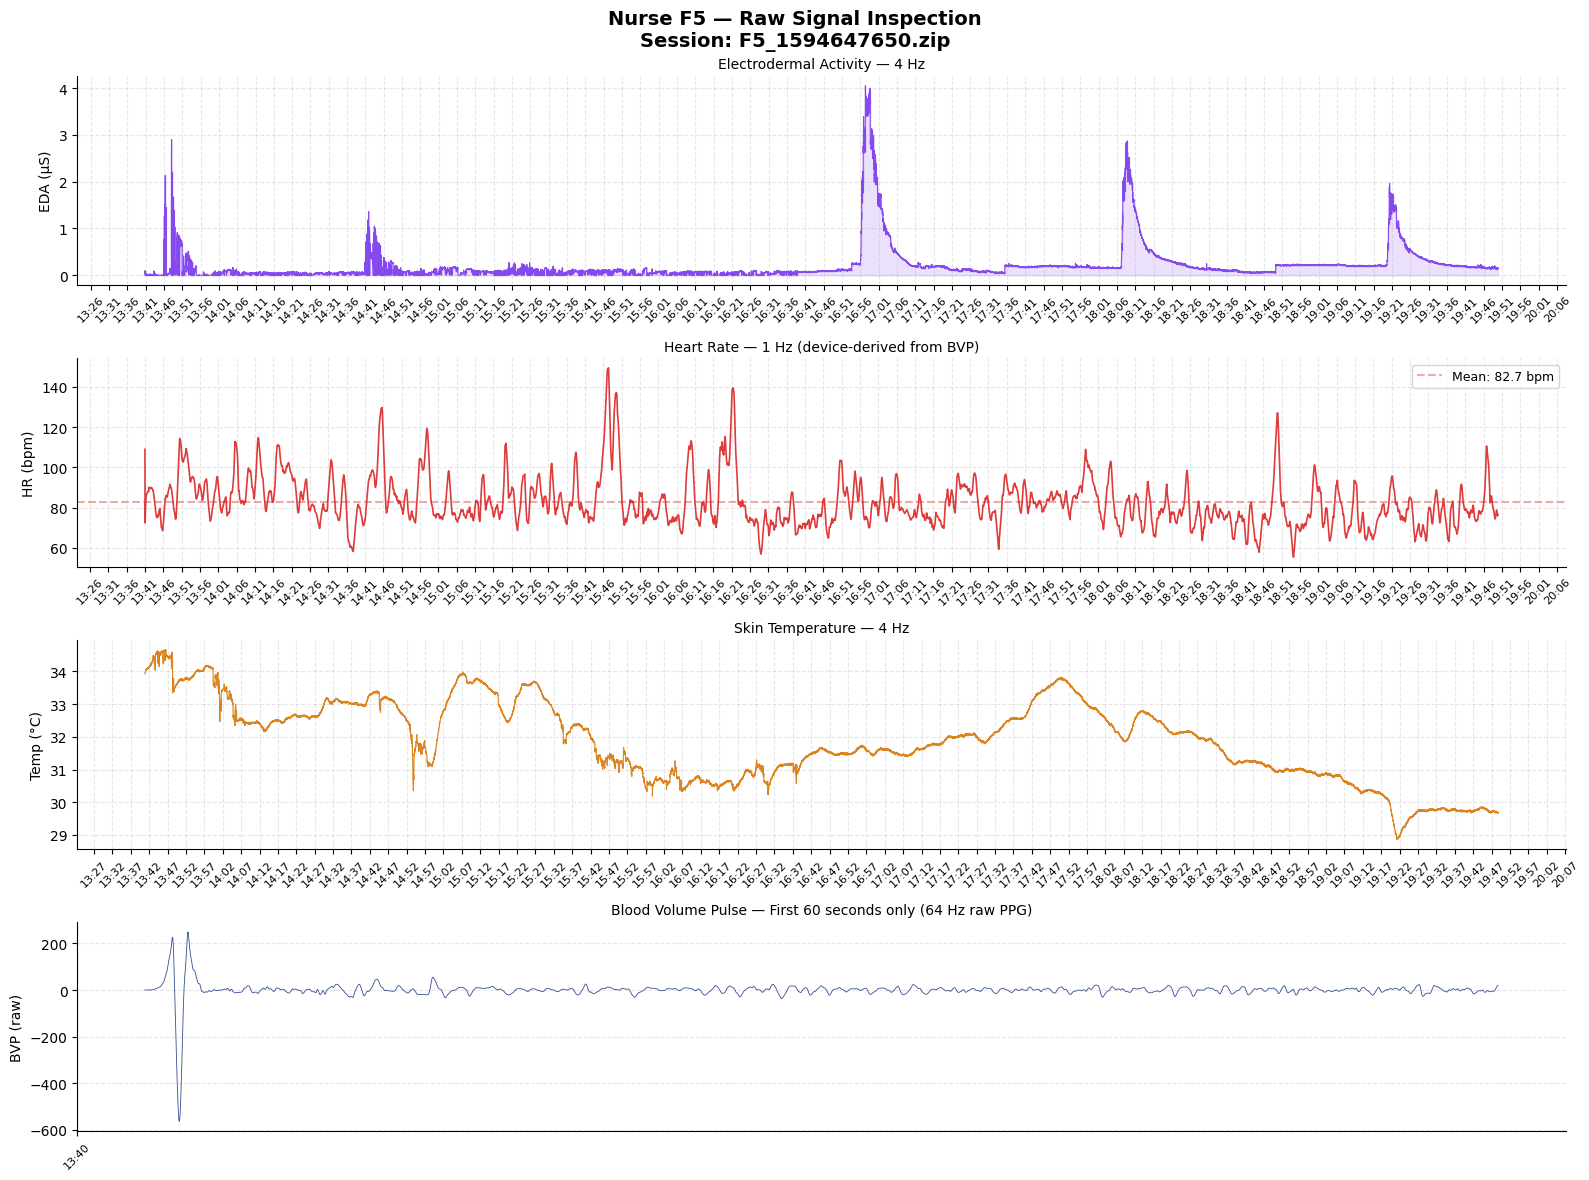


  ✓ Figure saved to Drive: /content/drive/MyDrive/CareSense_Research/Figures/nurse_F5_raw_signals.png

  RESEARCH OBSERVATION: Write down what you see.
  - Does EDA show any visible spikes?
  - Is HR relatively stable or highly variable?
  - Are there any obvious artifacts (sudden jumps to 0 or extreme values)?
  - What is the approximate baseline EDA level for this nurse?


In [ ]:
# Load all four main signals from the largest session
print("Loading signals for visualisation...")

eda_df,  _, _ = decode_e4_signal(largest_path, 'EDA')
hr_df,   _, _ = decode_e4_signal(largest_path, 'HR')
temp_df, _, _ = decode_e4_signal(largest_path, 'TEMP')

# For BVP, only load first 60 seconds (64Hz × 60s = 3840 points)
# Full BVP is very dense — first minute is enough to see waveform
bvp_df,  _, _ = decode_e4_signal(largest_path, 'BVP')
bvp_short = bvp_df.iloc[:3840]

print(f"  EDA loaded:  {len(eda_df):,} samples")
print(f"  HR loaded:   {len(hr_df):,} samples")
print(f"  TEMP loaded: {len(temp_df):,} samples")
print(f"  BVP loaded:  {len(bvp_df):,} samples (showing first 60s)")

# ── Create 4-panel visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle(
    f'Nurse {SAMPLE_NURSE} — Raw Signal Inspection\n'
    f'Session: {largest_zip}',
    fontsize=14, fontweight='bold', y=0.98
)

# Panel 1 — EDA
axes[0].plot(eda_df.index, eda_df['EDA'],
             color='#7C3AED', linewidth=0.8, alpha=0.9)
axes[0].set_ylabel('EDA (µS)', fontsize=10)
axes[0].set_title('Electrodermal Activity — 4 Hz', fontsize=10)
axes[0].fill_between(eda_df.index, eda_df['EDA'],
                     alpha=0.15, color='#7C3AED')

# Panel 2 — HR
axes[1].plot(hr_df.index, hr_df['HR'],
             color='#DC2626', linewidth=1.2, alpha=0.9)
axes[1].set_ylabel('HR (bpm)', fontsize=10)
axes[1].set_title('Heart Rate — 1 Hz (device-derived from BVP)', fontsize=10)
axes[1].axhline(hr_df['HR'].mean(), color='#DC2626',
                linestyle='--', alpha=0.4,
                label=f'Mean: {hr_df["HR"].mean():.1f} bpm')
axes[1].legend(fontsize=9)

# Panel 3 — TEMP
axes[2].plot(temp_df.index, temp_df['TEMP'],
             color='#D97706', linewidth=0.8, alpha=0.9)
axes[2].set_ylabel('Temp (°C)', fontsize=10)
axes[2].set_title('Skin Temperature — 4 Hz', fontsize=10)

# Panel 4 — BVP (first 60 seconds only — too dense for full session)
axes[3].plot(bvp_short.index, bvp_short['BVP'],
             color='#1E3A8A', linewidth=0.6, alpha=0.9)
axes[3].set_ylabel('BVP (raw)', fontsize=10)
axes[3].set_title('Blood Volume Pulse — First 60 seconds only (64 Hz raw PPG)', fontsize=10)

# Format x-axis timestamps on all panels
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save to Drive
fig_path = os.path.join(FIGURES_PATH, f'nurse_{SAMPLE_NURSE}_raw_signals.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  ✓ Figure saved to Drive: {fig_path}")
print("\n  RESEARCH OBSERVATION: Write down what you see.")
print("  - Does EDA show any visible spikes?")
print("  - Is HR relatively stable or highly variable?")
print("  - Are there any obvious artifacts (sudden jumps to 0 or extreme values)?")
print("  - What is the approximate baseline EDA level for this nurse?")